In [22]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from sklearn.metrics import confusion_matrix

### Hyperparameters

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 256
max_epoch = 10
train_iters = 5000
alpha = 0.001
decay = 0.0001
eval_iters = 1000
dropout = 0.5
np.random.seed(0)
torch.manual_seed(0)

### Training Data Reading and Map generation

#### Creating mapping for class to char

In [24]:
maps = open("OCR Neural Network/Datasets/emnist-balanced-mapping.txt",'r')
maps = {int(i):chr(int(j)) for i,j in [line.split() for line in maps.readlines()]}

#### Train Data Reading

In [25]:
# Load training data Set
with open("OCR Neural Network/Datasets/emnist-balanced-train.csv", "r") as f:
    reader = csv.reader(f)
    data_clump = np.array(list(reader), dtype=np.uint8)

#### Test Data Reading

In [26]:
with open("OCR Neural Network/Datasets/emnist-balanced-test.csv", "r") as f:
    reader = csv.reader(f)
    test_data_clump = np.array(list(reader), dtype=np.uint8)

### Data pre processing

In [27]:
#creating the training set
head_train = data_clump[:,0] 
img_px_train = data_clump[:,1:]

#normalizing the data
trainmean = np.mean(img_px_train)
trainstd = np.std(img_px_train)
img_px_train = (img_px_train - trainmean) / trainstd
img_px_train = img_px_train.reshape(-1, 28, 28)

#creating the test set
head_test = test_data_clump[:,0] 
img_px_test = test_data_clump[:,1:]

#normalizing the data
img_px_test = (img_px_test - trainmean) / trainstd
img_px_test = img_px_test.reshape(-1, 28, 28)

In [28]:
'''
No need to reshape and use pillow to convert to image.
EMNIST dataset already has rotations embedded in it.
'''
frame_train = pd.DataFrame({'Label' : head_train,  'Image' : img_px_train.tolist()})
frame_test = pd.DataFrame({'Label' : head_test,  'Image' : img_px_test.tolist()})

In [ ]:
def get_batch(split):
    data = frame_train if split == 'train' else frame_test
    data = data.sample(batch_size)
    X = torch.tensor(data['Image'].values.tolist(), dtype=torch.float32).view(-1, 1, 28, 28)
    y = torch.tensor(data['Label'].values.tolist(), dtype=torch.long)
    X,y = X.to(device), y.to(device)
    return X, y

### Designing the CNN Layers for Processing
* A CNN or Convolution Neural Network applies Convultions on values input.

* In a CNN, each node is a convoltuion alogrithm with some specified weight of convolution, a value to multiply the underlying value by. Suppose w1 for n1 is defined as 0.5, then the convolution will take w1*p1 for the case of the output x1

* In the CNN Layer, a 2D Convolution then takes in the entire image (grey scale 1 channel) and spits out a series of maps that with channels of N_out_channels.

* These channels could embed features in the weights or such. Each weight is mapped by the kernel so, if kernal is N size, there will be $N^2$ weights

In [ ]:
class CNNLayer(nn.Module):
    #Define the first layer of the CNN
    def __init__(self, *args, **kwargs) -> None:
        super(CNNLayer, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3) # 28x28x1 -> 26x26x32
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 26x26x32 -> 13x13x32

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64*13*13, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 47)

        self.activation = nn.GELU()
        self.dropout = nn.Dropout(p=dropout)
        self.output_activation = nn.GELU()
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.activation(out)
        out = self.pool1(out)

        out = self.flatten(out)
        
        out = self.fc1(out)
        out = self.activation(out)

        out = self.fc2(out)
        out = self.activation(out)

        out = self.fc3(out)
        out = self.output_activation(out)

        out = F.softmax(out, dim=1)
        return out

### Creating the Model

In [ ]:
class OCRCNN(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super(OCRCNN, self).__init__()
        self.hidden = CNNLayer()

    def forward(self, x, train_target = None):
        
        # Run through the Main Hidden Layers of the CNN
        out = self.hidden(x)

        if train_target is not None:
            loss = F.cross_entropy(out, train_target)
            return out, loss
        
        return out,None
    
    def predict(self, frame, size):
        frame = frame.sample(size)
        X = torch.tensor(frame['Image'].values.tolist(), dtype=torch.float32).view(-1, 1, 28, 28)
        y = np.array(frame['Label'].values.tolist(), dtype=np.int64)
        
        X, y = X.to(device), torch.tensor(y).to(device)
        
        self.eval()  # Set model to evaluation mode
        with torch.no_grad():
            out = self.hidden(X)
            _, predicted = torch.max(out, 1)
        
        conf_matrix = confusion_matrix(y.cpu(), predicted.cpu())
        print([maps[i] for i in predicted.cpu().numpy()])
        print([maps[i] for i in y.cpu().numpy()])
        plt.imshow(conf_matrix, cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.show()
        
        return None

In [11]:
model = OCRCNN()
m = model.to(device)

sum(p.numel() for p in m.parameters()),"parameters"

(5610671, 'parameters')

In [12]:
Counter = 0
train_losses = []
val_losses = []

In [13]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    out['accuracy'] = get_accuracy()
    model.train()
    return out

@torch.no_grad()
def get_accuracy():
    model.eval()
    correct = 0
    total = 0
    for i in range(1000):
        X, Y = get_batch('val')
        logits, _ = model(X, Y)
        _, predicted = torch.max(logits, 1)
        total += Y.size(0)
        correct += (predicted == Y).sum().item()
    model.train()
    return correct / total

In [19]:
#Adjustment For Plateau
aplha = 0.0004
decay = 0.00004

max_epoch = 1

In [20]:
optimizer = torch.optim.AdamW(m.parameters(), lr=alpha, weight_decay=decay)

for epoch in range(max_epoch):
    model.train()
    for i in range(train_iters):
        if i % eval_iters == 0 or i == train_iters - 1:
            losses = estimate_loss()
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            acc = losses['accuracy']
            print(f'Epoch {epoch}, Iteration {Counter}')
            print(f'Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f} : Accuracy: {acc:.4f}')
            Counter += 1000

        
        X_tr, Y_tr = get_batch('train')

        optimizer.zero_grad()

        out,loss = m(X_tr, Y_tr)

        loss.backward()
        optimizer.step()


Epoch 0, Iteration 72000
Training Loss: 3.0879, Validation Loss: 3.1382 : Accuracy: 0.7476
Epoch 0, Iteration 73000
Training Loss: 3.0900, Validation Loss: 3.1396 : Accuracy: 0.7465
Epoch 0, Iteration 74000
Training Loss: 3.0956, Validation Loss: 3.1436 : Accuracy: 0.7419
Epoch 0, Iteration 75000
Training Loss: 3.0932, Validation Loss: 3.1432 : Accuracy: 0.7434
Epoch 0, Iteration 76000
Training Loss: 3.0904, Validation Loss: 3.1427 : Accuracy: 0.7434
Epoch 0, Iteration 77000
Training Loss: 3.0875, Validation Loss: 3.1405 : Accuracy: 0.7434


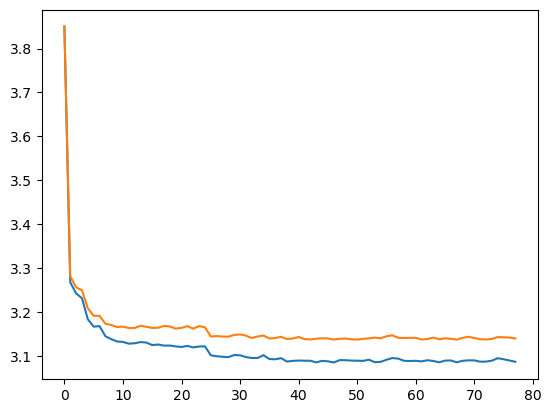

Training Done
['E', 'V', '0', '2', '8', 'I', 'F', 'Z', 'r', 'R', 'B', '9', 'H', 't', 'H', 'Y', 'C', '7', '9', 'A', 'r', 'X', 'I', '5', 'J', 'M', '1', '9', 't', 'G', 'b', 'q', '8', 'U', 't', 'E', 'L', 'a', 'R', 'U', 'b', '1', 'W', 'H', 'S', 'D', 'U', 'a', 'Y', 'A', 'Z', 'Z', '0', 'T', 'B', 'b', 't', 'a', '9', '2', 'L', 'g', 'B', '0', 'J', 'b', 'T', '5', 'M', 'b', 'K', 'Z', 'L', '5', '7', 'h', 'T', 'V', 'D', 'B', 'g', 'A', 'W', 'K', '3', '1', 'a', 'X', 'A', '7', 'J', 't', 'T', 'B', 'H', 'K', 'X', 'C', '4', 'M', 'I', 'G', '9', 'J', 'B', 'H', 'S', 'V', '2', 'U', 'h', '7', 'P', 'A', '0', 'A', '1', '5', 't', 'M', '3', 'M', '0', 'h', 'M', 't', '2', 'U', 'L', 'E', 'Y', 'b', '0', 'a', 'W', '3', 'T', 'a', 'O', 'P', '7', '8', 'D', 'W', 'b', '5', 'U', 'C', 'h', 'T', '0', '9', 'r', 'P', 'b', 'I', 'M', '4', 'G', 'Z', 'B', 'r', '7', 'B', '1', 'G', 'R', '0', '8', 'R', 'Y', '8', 'G', '8', 'H', '2', 'C', 'Z', 'L', 'M', 'I', 't', 'D', 'M', 'Z', '4', 'a', 'H', 'W', '7', 'b', 'J', 'U', 'g', '3', 'H', 'G', 

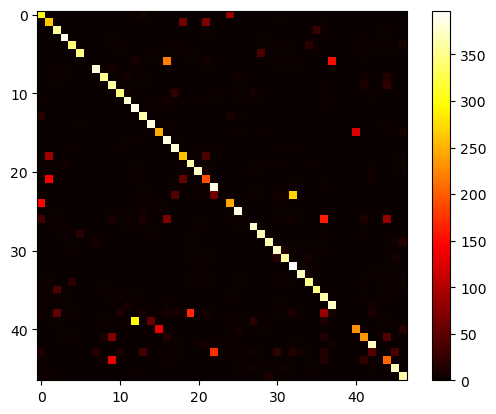

In [21]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.show()
print('Training Done')
m.predict(frame_test, frame_test.shape[0])

### Checking State Dicts of Model and Optim

In [ ]:
print('Model State Dict')
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model State Dict
hidden.conv1.weight 	 torch.Size([32, 1, 3, 3])
hidden.conv1.bias 	 torch.Size([32])
hidden.fc1.weight 	 torch.Size([512, 5408])
hidden.fc1.bias 	 torch.Size([512])
hidden.fc2.weight 	 torch.Size([128, 512])
hidden.fc2.bias 	 torch.Size([128])
hidden.fc3.weight 	 torch.Size([47, 128])
hidden.fc3.bias 	 torch.Size([47])


In [ ]:
print('Optimizer State Dict')
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Optimizer State Dict
state 	 {0: {'step': tensor(5000.), 'exp_avg': tensor([[[[ 1.8190e-04,  1.0201e-04, -6.1365e-04],
          [ 1.6039e-03,  7.8631e-04, -5.0196e-04],
          [ 1.3544e-03,  2.5608e-04,  7.1799e-05]]],


        [[[ 7.1867e-06,  2.3890e-05, -6.1440e-04],
          [ 1.0257e-03,  1.7437e-04, -7.3959e-04],
          [ 5.5955e-04, -2.4857e-04, -1.8681e-04]]],


        [[[ 9.0108e-05,  2.8890e-04, -7.6137e-05],
          [ 4.8413e-04,  8.5229e-04,  5.5305e-04],
          [-4.1085e-04,  9.3053e-05, -1.6534e-04]]],


        [[[-3.1747e-03, -3.6146e-03, -3.4725e-03],
          [-3.4557e-03, -3.5731e-03, -3.5029e-03],
          [-3.2765e-03, -3.3705e-03, -3.0362e-03]]],


        [[[-1.5425e-03, -8.1756e-04, -7.6703e-05],
          [-2.7132e-03, -1.2548e-03,  3.1544e-04],
          [-1.7422e-03, -3.0169e-04,  4.0136e-04]]],


        [[[-1.8573e-03, -1.1079e-03, -7.0294e-04],
          [-1.6585e-03, -8.0861e-04, -7.3611e-04],
          [-1.1218e-03, -2.9555e-04, -6.8787e

### Saving Model Checkpoint

In [ ]:
torch.save(model.state_dict(), 'OCR Neural Network/OCRModel_3.015_3.0721_0.815.pth')

In [ ]:
torch.save(optimizer.state_dict(), 'OCR Neural Network/Optimizer_3.015_3.0721_0.815.pth')

In [ ]:
@torch.no_grad()
def estimate_loss2():
    out = {}
    model2.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model2(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model2.train()
    return out

@torch.no_grad()
def get_accuracy():
    model2.eval()
    correct = 0
    total = 0
    for i in range(1000):
        X, Y = get_batch('val')
        logits, _ = model2(X, Y)
        _, predicted = torch.max(logits, 1)
        total += Y.size(0)
        correct += (predicted == Y).sum().item()
    model2.train()
    return correct / total

In [ ]:
model2 = OCRCNN()
model2.load_state_dict(torch.load(r'OCR Neural Network\OCR_3.1446_3.1564 GELU+LR_drop_1e-6\OCRModel_3.1446_3.1564.pth'))
model2.eval()
model2 = model2.to(device)
model2.predict(frame_test, frame_test.shape[0])
get_accuracy()